# AMLGuard: Anti-Money Laundering Detection under Extreme Class Imbalance

**Author:** Caio Bernardinelli  
**Date:** June 2026  
**Course:** Técnico em Inteligência Artificial — IFNMG  
**Objective:** Build a machine-learning pipeline to detect money-laundering transactions in the IBM AML dataset under extreme class imbalance.

---

## 1. Dataset Presentation

### Business context

The European Union's **Anti-Money Laundering Authority (AMLA)** is headquartered in Frankfurt and began most of its activities in 2025. On **1 January 2026**, AMLA assumed the EU-level AML/CFT mandates previously held by the European Banking Authority (EBA). AMLA plans to select up to 40 high-risk financial-sector entities in 2027 for direct supervision beginning in 2028.

Official references:
- [EBA and AMLA complete the handover of AML/CFT mandates](https://www.amla.europa.eu/eba-and-amla-complete-handover-amlcft-mandates_en)
- [AMLA risk-assessment work supporting the selection of directly supervised entities](https://www.amla.europa.eu/amla-launch-data-collection-exercise-test-risk-assessment-models-financial-sector_en)

The technical challenge addressed by this project is **extreme class imbalance**. Illicit transactions represent approximately 0.1% of this dataset. A classifier that labels every transaction as legitimate would therefore achieve about 99.9% accuracy while detecting no laundering. The project consequently prioritises precision–recall metrics, threshold selection and operational alert quality rather than accuracy alone.

### Dataset

**Source:** IBM Transactions for Anti-Money Laundering (AML)  
**Link:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml  
**License:** Community Data License Agreement — Sharing — Version 1.0  
**Version used:** HI-Small (high illicit ratio; smallest version for rapid iteration)

### Variable description

| Column | Type | Description |
|---|---|---|
| Timestamp | object | Date and time of the transaction |
| From Bank | int64 | Identifier of the sending bank |
| Account | object | Account number of the sender |
| To Bank | int64 | Identifier of the receiving bank |
| Account.1 | object | Account number of the receiver |
| Amount Received | float64 | Amount received by the destination account |
| Receiving Currency | object | Currency of the received amount |
| Amount Paid | float64 | Amount paid by the source account |
| Payment Currency | object | Currency of the paid amount |
| Payment Format | object | Payment method, such as Cheque, Wire or Reinvestment |
| Is Laundering | int64 | **Target variable** — 1 = illicit, 0 = legitimate |

> **Dataset limitation:** the data are synthetic and cover only 18 days. Strong patterns may reflect simulator rules rather than generalisable real-world laundering behaviour. Every high-lift feature is therefore interpreted critically.


In [1]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================

from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preparation and baseline modelling
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Global random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Core libraries imported successfully")
print(f"✓ Random state fixed: {RANDOM_STATE}")


✓ Core libraries imported successfully
✓ Random state fixed: 42


## 2. Data Loading

The `HI-Small_Trans.csv` file is ~476 MB and is hosted on Google Drive rather than committed to the repository (the `.gitignore` excludes `*.csv`). It is downloaded at runtime with `gdown`, so the notebook is fully reproducible from a fresh clone: anyone running it fetches the data automatically, without needing the file in version control.

After loading, we run a first inspection — shape, column names, data types, memory footprint, and the distribution of the target variable — to confirm the data arrived intact and to quantify the class imbalance before any analysis.

In [2]:
# ============================================================================
# 2. DATA LOADING
# ============================================================================

print("=" * 80)
print("2. DATA LOADING")
print("=" * 80)

DATA_PATH = Path("HI-Small_Trans.csv")
FILE_ID = "1359N_tsRuUtCFMWCV6BtHjDdF280rb8e"

if not DATA_PATH.exists():
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        str(DATA_PATH),
        quiet=False,
    )
else:
    print(f"✓ Reusing local file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

TARGET = "Is Laundering"
BASE_RATE = df[TARGET].mean()

print(f"\n✓ Dataset loaded successfully")
print(f"\n{'─' * 40}")
print(f"Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'─' * 40}")

print("\n--- First 10 rows ---")
print(df.head(10))

print("\n--- Data types ---")
print(df.dtypes)

print(f"\n--- Target variable ({TARGET}) ---")
print(df[TARGET].value_counts())
print(f"\nIllicit transactions: {BASE_RATE:.4%}")


2. DATA LOADING


Downloading...
From (original): https://drive.google.com/uc?id=1359N_tsRuUtCFMWCV6BtHjDdF280rb8e
From (redirected): https://drive.google.com/uc?id=1359N_tsRuUtCFMWCV6BtHjDdF280rb8e&confirm=t&uuid=cec0dff1-dc69-45ad-8754-5fcff01575ea
To: /content/HI-Small_Trans.csv
100%|██████████| 476M/476M [00:08<00:00, 58.2MB/s]



✓ Dataset loaded successfully

────────────────────────────────────────
Shape:        5,078,345 rows × 11 columns
Memory usage: 1890.96 MB
────────────────────────────────────────

--- First 10 rows ---
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   
5  2022/09/01 00:03          1  8000F5AD0        1  8000F5AD0   
6  2022/09/01 00:08          1  8000EBAC0        1  8000EBAC0   
7  2022/09/01 00:16          1  8000EC1E0        1  8000EC1E0   
8  2022/09/01 00:26         12  8000EC280     2439  8017BF800   
9  2022/09/01 00:21          1  8000EDEC0   211050  80AEF5310   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0        

**Key finding — the imbalance is even more extreme than expected.**

The dataset holds **5,078,345 transactions** across 11 columns. Only **5,177** are labelled as laundering — **0.1019%** of the total, roughly one illicit transaction in every 980. This is well below the "under 1%" rule of thumb and sets the methodological constraints for the entire pipeline: stratified train/test split, precision–recall-oriented metrics (PR-AUC) instead of accuracy, and explicit handling of imbalance (class weighting / resampling) during modelling.

## 3. Descriptive Analysis

Before modelling, we characterise the data and test three hypotheses about *where* laundering concentrates. Given the extreme imbalance (base rate 0.1019%), the guiding principle throughout this section is to compare **illicit rate**, not raw counts: a frequent category will naturally contain more illicit cases in absolute terms simply because it contains more of everything. What signals risk is a group whose *proportion* of laundering sits well above the global base rate.

Each hypothesis below follows the same pattern — derive a flag, group by it, and read the mean of the target (which, for a 0/1 column, is the illicit rate of the group).

In [3]:
# ============================================================================
# 3. DESCRIPTIVE ANALYSIS
# ============================================================================

print("="*80)
print("3. DESCRIPTIVE ANALYSIS")
print("="*80)

# --- 3.1 Numeric overview ---
print("\n--- Amount Paid / Received: statistics ---")
print(df[['Amount Paid', 'Amount Received']].describe())

# --- 3.2 Categorical cardinality ---
print("\n--- Cardinality of categorical variables ---")
for col in ['Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank', 'To Bank']:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n--- Payment Format distribution ---")
print(df['Payment Format'].value_counts())

print("\n--- Top 10 currencies (Payment) ---")
print(df['Payment Currency'].value_counts().head(10))

3. DESCRIPTIVE ANALYSIS

--- Amount Paid / Received: statistics ---
        Amount Paid  Amount Received
count  5.078345e+06     5.078345e+06
mean   4.509273e+06     5.988726e+06
std    8.697728e+08     1.037183e+09
min    1.000000e-06     1.000000e-06
25%    1.844800e+02     1.833700e+02
50%    1.414540e+03     1.411010e+03
75%    1.229784e+04     1.234627e+04
max    1.046302e+12     1.046302e+12

--- Cardinality of categorical variables ---
Receiving Currency: 15 unique values
Payment Currency: 15 unique values
Payment Format: 7 unique values
From Bank: 30470 unique values
To Bank: 15811 unique values

--- Payment Format distribution ---
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

--- Top 10 currencies (Payment) ---
Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            2137

### H1 — Cross-currency transactions

**Hypothesis:** moving money across currencies (paid ≠ received currency) could help shift wealth across borders and hinder tracing.

**Reading:** the hypothesis **cannot be tested on this dataset**. Cross-currency transactions are only 1.42% of all records (72,170 of 5.08M), and — decisively — **none** of them are labelled as laundering (0 illicit in 72,170). All 5,177 illicit cases are same-currency. This is a property of the synthetic generator, which never tags a cross-currency transaction as illicit, rather than an economic pattern. The flag therefore acts as a perfect *negative* predictor (cross-currency ⇒ certainly legitimate), which is a simulator artifact and not a generalizable signal. It will be **excluded** from modelling to avoid leakage, and noted as a dataset limitation in the conclusion.

In [4]:
df['is_cross_currency'] = (df['Payment Currency'] != df['Receiving Currency']).astype(int)
df.groupby('is_cross_currency')['Is Laundering'].agg(['mean', 'count', 'sum'])


,mean,count,sum
is_cross_currency,,,
0,0.001034,5006175,5177
1,0.000000,72170,0


In [5]:
print("--- Cross-currency distribution ---")
print(df["is_cross_currency"].value_counts(normalize=True) * 100)


--- Cross-currency distribution ---
is_cross_currency
0    98.578868
1     1.421132
Name: proportion, dtype: float64


### H2 — Payment format and laundering

**Hypothesis:** some payment methods offer easier laundering channels, so their illicit rate should exceed the global base rate (0.1019%).

**Reading:** only **ACH** stands out. Its illicit rate is **0.7462%** — about **7.3× the global base rate** — and it concentrates **86.6%** of all illicit cases. Crucially, the intuition that low-traceability channels (Bitcoin, Cash) would lead does **not** hold here: Bitcoin (0.0383%) and Cash (0.0220%) sit *below* the base rate, so a transaction in those formats is, if anything, *less* likely to be illicit than average. Their apparent prominence among illicit cases was a volume artifact (Reading B), not elevated risk (Reading A). Two formats — Reinvestment and Wire — contain **zero** illicit cases across hundreds of thousands of transactions, mirroring the generator-rule pattern seen in H1. ACH is therefore the only payment-format signal worth keeping as a feature, but its 7× concentration likely reflects how the synthetic generator routes laundering events rather than a real-world property of ACH, and is flagged as a dataset bias in the conclusion.

In [6]:
df.groupby('Payment Format')['Is Laundering'].agg(['mean', 'count', 'sum'])

,mean,count,sum
Payment Format,,,
ACH,0.007462,600797,4483
Bitcoin,0.000383,146091,56
Cash,0.000220,490891,108
Cheque,0.000174,1864331,324
Credit Card,0.000156,1323324,206
Reinvestment,0.000000,481056,0
Wire,0.000000,171855,0


In [7]:
fmt = df.groupby('Payment Format')['Is Laundering'].agg(['mean', 'count', 'sum'])

fmt = fmt.rename(columns={
    'mean':  'illicit_rate',     # illicit rate WITHIN the format (Reading A)
    'count': 'n_transactions',   # total volume of the format
    'sum':   'n_illicit'         # absolute illicit count
})

# Reading A — illicit rate within the format, as %
fmt['illicit_rate_%'] = (fmt['illicit_rate'] * 100).round(4)

# Legitimate rate within the format (complement of the illicit rate)
fmt['legit_rate_%'] = (100 - fmt['illicit_rate_%']).round(4)

# Reading B — how much each format represents of all illicit cases
fmt['%_of_all_illicit'] = (fmt['n_illicit'] / fmt['n_illicit'].sum() * 100).round(2)

# Context — how much each format represents of total volume
fmt['%_of_all_tx'] = (fmt['n_transactions'] / fmt['n_transactions'].sum() * 100).round(2)

fmt = fmt[['n_transactions', '%_of_all_tx', 'n_illicit',
           '%_of_all_illicit', 'illicit_rate_%', 'legit_rate_%']]
fmt = fmt.sort_values('illicit_rate_%', ascending=False)

print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(fmt)

Global base rate: 0.1019%

                n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
Payment Format                                                             
ACH                     600797        11.83       4483             86.59   
Bitcoin                 146091         2.88         56              1.08   
Cash                    490891         9.67        108              2.09   
Cheque                 1864331        36.71        324              6.26   
Credit Card            1323324        26.06        206              3.98   
Reinvestment            481056         9.47          0              0.00   
Wire                    171855         3.38          0              0.00   

                illicit_rate_%  legit_rate_%  
Payment Format                                
ACH                     0.7462       99.2538  
Bitcoin                 0.0383       99.9617  
Cash                    0.0220       99.9780  
Cheque                  0.0174       99.9826  
Credit

### H3 — Same-bank vs. cross-bank transactions

**Hypothesis:** transactions between different banks or accounts could facilitate laundering by moving funds away from their point of origin.

**Reading:** the direction holds descriptively, but the effect is **weak**. Cross-bank transactions show an illicit rate of **0.1157%** versus **0.0149%** for same-bank transactions. However, the cross-bank rate is only **1.14× the global base rate** of 0.1019%, far below the lift observed for ACH. The fact that 98% of illicit cases are cross-bank is not sufficient evidence by itself because 86% of all transactions are already cross-bank; the relevant comparison is the rate within each group.

At this stage, `same_bank` is retained only as a **candidate**. Section 5 later introduces the more granular `same_account` flag and shows high redundancy between them, so `same_bank` is removed from the final feature set rather than presenting both versions of the same structural signal to the model.


In [8]:
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype(int)
df.groupby('same_bank')['Is Laundering'].agg(['mean', 'count', 'sum'])

,mean,count,sum
same_bank,,,
0,0.001157,4387013,5074
1,0.000149,691332,103


In [9]:
same_bank = df.groupby('same_bank')['Is Laundering'].agg(['mean', 'count', 'sum'])
same_bank = same_bank.rename(columns={'mean': 'illicit_rate', 'count': 'n_transactions', 'sum': 'n_illicit'})
same_bank['illicit_rate_%'] = (same_bank['illicit_rate'] * 100).round(4)
same_bank['%_of_all_tx'] = (same_bank['n_transactions'] / same_bank['n_transactions'].sum() * 100).round(2)
same_bank['%_of_all_illicit'] = (same_bank['n_illicit'] / same_bank['n_illicit'].sum() * 100).round(2)
same_bank = same_bank.rename(index={0: 'Different banks', 1: 'Same bank'})
print(f"Global base rate: {df['Is Laundering'].mean()*100:.4f}%\n")
print(same_bank[['n_transactions', '%_of_all_tx', 'n_illicit', '%_of_all_illicit', 'illicit_rate_%']])

Global base rate: 0.1019%

                 n_transactions  %_of_all_tx  n_illicit  %_of_all_illicit  \
same_bank                                                                   
Different banks         4387013        86.39       5074             98.01   
Same bank                691332        13.61        103              1.99   

                 illicit_rate_%  
same_bank                        
Different banks          0.1157  
Same bank                0.0149  


**Section summary**

The three initial hypotheses produced one strong signal, one weak structural candidate and one clear simulator artifact. The methodological lesson across all analyses is to compare the illicit **rate within each group**, never raw counts: high-volume categories naturally accumulate more illicit cases even when their underlying risk is low.

- **H1 — Cross-currency:** not meaningfully testable in this dataset. The 72,170 cross-currency transactions contain zero illicit labels, creating an unrealistically perfect negative predictor. The feature is excluded as a generator artifact and leakage risk.
- **H2 — Payment format:** ACH is the strongest observed signal, with an illicit rate of 0.7462% (7.3× the base rate) and 86.6% of all illicit labels. Bitcoin and Cash remain below the base rate. Payment format is retained, while its unusually strong synthetic pattern is documented as a limitation.
- **H3 — Same bank vs. different banks:** the direction is consistent with the hypothesis but the lift is weak. `same_bank` remains a temporary candidate here and is later removed after the more granular `same_account` flag is created and their redundancy is measured.

**Implication for modelling:** accuracy is not an adequate primary metric at a 0.1019% base rate. Evaluation will use Average Precision / precision–recall analysis, recall at an operationally acceptable precision, and confusion-matrix counts. Zero-illicit categories and other unusually strong rules are treated as possible simulator behaviour rather than automatically accepted as real-world AML knowledge.


## 4. Data Cleaning

This dataset is synthetic and generated by IBM's multi-agent simulator, so it is expected to arrive with high integrity and without the noise typical of real-world financial data. Rather than assuming this, the checks below verify it explicitly: missing values, exact duplicates, data types, and timestamp parseability.

> **Note on ordering:** cleaning is presented after the descriptive analysis (Section 3) for narrative flow, but the checks below confirm the dataset was already complete and well-typed — so the Section 3 conclusions rest on untreated, intact data, with no risk of contamination from missing or malformed values.

In [10]:
# ============================================================================
# 4. DATA CLEANING
# ============================================================================

print("="*80)
print("4. DATA CLEANING")
print("="*80)

# --- 4.1 Missing values ---
print("\n--- Missing values per column ---")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_table = pd.DataFrame({'n_missing': missing, 'pct_%': missing_pct})
print(missing_table[missing_table['n_missing'] > 0] if missing.sum() > 0 else "No missing values found.")

# --- 4.2 Duplicates (full-row) ---
print("\n--- Full-row duplicates ---")
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.4f}%)")

# --- 4.3 Data types check ---
print("\n--- Current dtypes ---")
print(df.dtypes)

# --- 4.4 Timestamp parsing check ---
print("\n--- Timestamp: parseable check ---")
parsed = pd.to_datetime(df['Timestamp'], errors='coerce')
print(f"Failed to parse: {parsed.isna().sum():,} of {len(df):,}")
print(f"Date range: {parsed.min()} → {parsed.max()}")

4. DATA CLEANING

--- Missing values per column ---
No missing values found.

--- Full-row duplicates ---
Exact duplicate rows: 9 (0.0002%)

--- Current dtypes ---
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
is_cross_currency       int64
same_bank               int64
dtype: object

--- Timestamp: parseable check ---
Failed to parse: 0 of 5,078,345
Date range: 2022-09-01 00:00:00 → 2022-09-18 16:18:00


**Cleaning decisions**

| Check | Result | Decision & justification |
|---|---|---|
| Missing values | 0 across all 11 columns | No imputation required — the dataset is complete. |
| Exact duplicate rows | 9 rows (0.0002%) | **Kept.** Identical rows in a transaction log may be legitimate repeated payments; with only 9 cases in 5.08M, there is no evidence they are errors and no measurable impact, so they were preserved and documented rather than dropped on assumption. |
| Data types | All consistent; `Timestamp` stored as object | Will be parsed to datetime in Section 5 for temporal feature extraction. |
| Timestamp parseability | 100% parseable (0 failures) | Range: 2022-09-01 → 2022-09-18 — a dense 18-day window, relevant for velocity-based features in Section 5. |

**Conclusion:** The dataset required no cleaning. Being synthetic and generated under controlled conditions, it arrived complete (zero missing values), well-typed, and with fully parseable timestamps. No values were imputed and no rows were dropped; the only observation of note is 9 exact duplicates (0.0002%), kept as plausibly legitimate. This confirms that the Section 3 conclusions rest on intact data.

## 5. Exploratory Data Analysis & Feature Engineering

This section has two goals: (1) visualise how the main variables distribute across the two classes, and (2) turn the validated signals from Section 3 into model-ready features. The guiding question throughout remains *what distinguishes the <0.11% illicit minority?* Every candidate feature is judged by the same rule used in Section 3 — illicit **rate** within a group versus the global base rate (0.1019%), never raw counts.

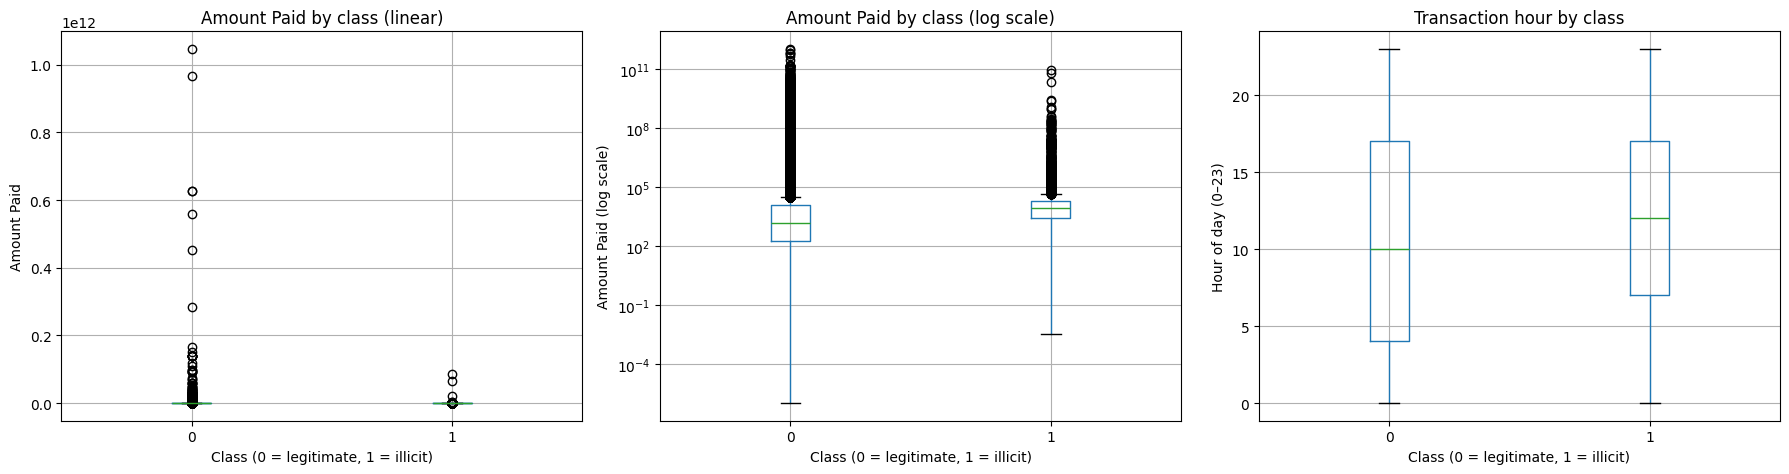

Global base rate: 0.1019%

--- Illicit rate by hour ---
       count  sum  illicit_rate_%
Hour                             
0     634726  176          0.0277
1     193728  152          0.0785
2     193143  165          0.0854
3     193249  146          0.0756
4     193166  154          0.0797
5     193900  188          0.0970
6     194456  207          0.1065
7     193336  195          0.1009
8     192921  258          0.1337
9     192952  217          0.1125
10    193229  234          0.1211
11    193500  295          0.1525
12    192972  336          0.1741
13    192521  292          0.1517
14    192787  279          0.1447
15    194871  263          0.1350
16    193407  311          0.1608
17    193154  257          0.1331
18    193321  255          0.1319
19    192824  231          0.1198
20    192809  134          0.0695
21    192192  154          0.0801
22    191836  128          0.0667
23    193345  150          0.0776

--- Business-hours feature validation (08:00–18:59) ---
   

In [11]:
# ============================================================================
# 5. EXPLORATORY DATA ANALYSIS — distributions by class
# ============================================================================

# Parse the timestamp once and derive temporal features.
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["is_business_hours"] = df["Hour"].between(8, 18).astype("int8")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 5.1 Amount by class (linear scale) ---
df.boxplot(column="Amount Paid", by=TARGET, ax=axes[0])
axes[0].set_title("Amount Paid by class (linear)")
axes[0].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[0].set_ylabel("Amount Paid")

# --- 5.2 Amount by class (log scale) ---
df.boxplot(column="Amount Paid", by=TARGET, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Amount Paid by class (log scale)")
axes[1].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[1].set_ylabel("Amount Paid (log scale)")

# --- 5.3 Hour of day by class ---
df.boxplot(column="Hour", by=TARGET, ax=axes[2])
axes[2].set_title("Transaction hour by class")
axes[2].set_xlabel("Class (0 = legitimate, 1 = illicit)")
axes[2].set_ylabel("Hour of day (0–23)")

plt.suptitle("")
plt.tight_layout()
plt.show()

hourly = df.groupby("Hour", observed=False)[TARGET].agg(["count", "sum", "mean"])
hourly["illicit_rate_%"] = (hourly["mean"] * 100).round(4)

business_hours_stats = (
    df.groupby("is_business_hours", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
business_hours_stats["illicit_rate_%"] = (
    business_hours_stats["mean"] * 100
).round(4)
business_hours_stats["lift_vs_base"] = (
    business_hours_stats["mean"] / BASE_RATE
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by hour ---")
print(hourly[["count", "sum", "illicit_rate_%"]])

print("\n--- Business-hours feature validation (08:00–18:59) ---")
print(
    business_hours_stats[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
    .rename(index={0: "Outside business hours", 1: "Business hours"})
)


**5.1 Distributions by class**

**Transaction amount.** On a linear scale, legitimate transactions contain extreme outliers (up to approximately 1×10¹²), compressing most observations and making the classes visually indistinguishable. The log-scale view reveals limited additional structure: illicit values are somewhat more concentrated in a middle range, but amount alone does not provide clean separation. `Amount Paid` is therefore retained as a weak baseline numeric input rather than treated as a strong standalone signal.

**Transaction hour.** The hour-level illicit rate reveals a daily pattern that the boxplots do not show. The rate is lowest overnight and increases during the daytime, peaking at 12:00 at 0.1741%. However, the binary feature must be evaluated using the complete 08:00–18:59 group rather than the single peak hour. Across that full interval, the illicit rate is approximately **0.1410%**, or **1.38× the global base rate**. This remains a moderate and interpretable signal, but it is weaker than the previous peak-based description implied.

The pattern contradicts the original unusual-hours hypothesis: laundering in this synthetic dataset aligns more closely with normal business activity than with the early morning. This could represent attempts to blend into ordinary transaction volume, but it may also be a rule of the synthetic generator. Midnight contains substantially more records than most other hours, which is noted as an additional data-quality characteristic.


In [12]:
# Round-value flags at different granularities
df['round_100']  = (df['Amount Paid'] % 100 == 0).astype(int)
df['round_1000'] = (df['Amount Paid'] % 1000 == 0).astype(int)

base = df['Is Laundering'].mean() * 100
print(f"Global base rate: {base:.4f}%\n")

for col in ['round_100', 'round_1000']:
    print(f"--- {col} ---")
    t = df.groupby(col)['Is Laundering'].agg(['count', 'sum', 'mean'])
    t['illicit_rate_%'] = (t['mean'] * 100).round(4)
    print(t[['count', 'sum', 'illicit_rate_%']])
    print()

Global base rate: 0.1019%

--- round_100 ---
             count   sum  illicit_rate_%
round_100                               
0          5077718  5176          0.1019
1              627     1          0.1595

--- round_1000 ---
              count   sum  illicit_rate_%
round_1000                               
0           5078277  5177          0.1019
1                68     0          0.0000



In [13]:
# Leakage-safe velocity feature: number of earlier transactions by the sender.
# Sorting by time ensures that a row never uses future account activity.
# cumcount() uses no target information; the first observed transaction is zero.
df = df.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)
df["sender_previous_tx_count"] = (
    df.groupby("Account", sort=False)
      .cumcount()
      .astype("int32")
)

# Non-linear bands are used only for EDA. The model receives the numeric feature.
df["previous_velocity_band"] = pd.cut(
    df["sender_previous_tx_count"],
    bins=[-1, 0, 1, 5, 20, 100, float("inf")],
    labels=["0", "1", "2-5", "6-20", "21-100", "100+"],
)

velocity_stats = (
    df.groupby("previous_velocity_band", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
velocity_stats["illicit_rate_%"] = (velocity_stats["mean"] * 100).round(4)
velocity_stats["lift_vs_base"] = (velocity_stats["mean"] / BASE_RATE).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print(
    velocity_stats[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
)


Global base rate: 0.1019%

                          count   sum  illicit_rate_%  lift_vs_base
previous_velocity_band                                             
0                        496995   184          0.0370          0.36
1                        344245   625          0.1816          1.78
2-5                      579241  1648          0.2845          2.79
6-20                    1431536  1168          0.0816          0.80
21-100                  1673000   836          0.0500          0.49
100+                     553328   716          0.1294          1.27


**5.2 Feature engineering**

Each candidate feature is judged against the global illicit base rate of 0.1019%. Signals that depend on future information, simulator artifacts, sparse phenomena or redundant representations are not accepted merely because they produce attractive descriptive results.

**Payment format — kept, strongest observed signal.** ACH has an illicit rate of 0.7462% (approximately 7.3× the base rate) and contains 86.6% of all illicit labels. The entire categorical variable is retained and will be one-hot encoded with unknown-category handling. Its strength is also flagged as likely generator-dependent.

**Sender velocity — re-engineered to remove future information.** The first EDA version counted every transaction made by an account across the complete 18-day dataset. Although it did not use the target, it allowed each row to see account activity that occurred later and could cross the train/test boundary. That retrospective total is therefore not used as a model input. It is replaced by `sender_previous_tx_count`, which counts only earlier observed transactions by the sender after chronological sorting. The original 2–5 band result is retained only as an exploratory clue; the leakage-safe feature is re-evaluated in the code above before any modelling claim is made.

**Business hours — kept, moderate signal.** The binary `is_business_hours` feature represents 08:00–18:59. Its full-group illicit rate is approximately 0.1410%, or 1.38× the base rate. The 12:00 peak of 0.1741% remains an hourly finding, not the rate assigned to the binary feature.

**Same account — provisionally kept, but confounded.** Transfers between different accounts have a higher illicit rate than same-account records. However, every `Reinvestment` transaction is a same-account transaction and that payment format contains no illicit labels, so much of the separation may be generated by payment format. The feature is retained provisionally and must prove incremental value beyond one-hot-encoded `Payment Format`.

**Same bank — excluded after refinement.** `same_bank` was initially retained as a weak candidate, but it is highly redundant with the more granular `same_account` flag. Keeping both would add limited independent information, so `same_bank` is removed from the final input set.

**Cross-currency — excluded as a generator artifact.** All 72,170 cross-currency transactions are labelled legitimate. This unrealistically perfect negative rule would not be expected to generalise.

**Round-value flags — excluded because the phenomenon is effectively absent.** Only 627 amounts are multiples of 100 and only 68 are multiples of 1,000 in 5.08 million records. The sample is too sparse to support the hypothesis.

The feature set is now considered closed for the first modelling cycle. Additional feature testing before the baselines would be analysis without delivery; the next step is to determine whether these inputs generalise beyond descriptive EDA.


In [14]:
# Same account (origin == destination)
df["same_account"] = (df["Account"] == df["Account.1"]).astype("int8")

same_account_stats = (
    df.groupby("same_account", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
same_account_stats["illicit_rate_%"] = (
    same_account_stats["mean"] * 100
).round(4)
same_account_stats["%_of_all_tx"] = (
    same_account_stats["count"] / len(df) * 100
).round(2)
same_account_stats["lift_vs_base"] = (
    same_account_stats["mean"] / BASE_RATE
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by same-account flag ---")
print(
    same_account_stats[
        ["count", "%_of_all_tx", "sum", "illicit_rate_%", "lift_vs_base"]
    ].rename(index={0: "Different accounts", 1: "Same account"})
)

print("\n--- same_account vs Payment Format ---")
print(pd.crosstab(df["same_account"], df["Payment Format"]))

# Reproduce the redundancy checks cited in the final selection.
correlation_check = df[
    ["same_bank", "same_account", "Amount Paid", "Amount Received"]
].corr()

print("\n--- Redundancy checks ---")
print(f"Correlation: same_bank vs same_account = {correlation_check.loc['same_bank', 'same_account']:.3f}")
print(f"Correlation: Amount Paid vs Amount Received = {correlation_check.loc['Amount Paid', 'Amount Received']:.3f}")


Global base rate: 0.1019%

--- Illicit rate by same-account flag ---
                      count  %_of_all_tx   sum  illicit_rate_%  lift_vs_base
same_account                                                                
Different accounts  4487133        88.36  5166          0.1151          1.13
Same account         591212        11.64    11          0.0019          0.02

--- same_account vs Payment Format ---
Payment Format     ACH  Bitcoin    Cash   Cheque  Credit Card  Reinvestment  \
same_account                                                                  
0               529450   119774  489436  1858265      1319148             0   
1                71347    26317    1455     6066         4176        481056   

Payment Format    Wire  
same_account            
0               171060  
1                  795  

--- Redundancy checks ---
Correlation: same_bank vs same_account = 0.914
Correlation: Amount Paid vs Amount Received = 0.843


In [15]:
# Illicit rate by sending bank — descriptive analysis only.
bank_stats = df.groupby("From Bank")[TARGET].agg(["count", "sum", "mean"])
bank_stats["illicit_rate_%"] = (bank_stats["mean"] * 100).round(4)
bank_stats["lift_vs_base"] = (bank_stats["mean"] / BASE_RATE).round(2)

# Minimum support reduces, but does not eliminate, small-sample instability.
reliable_banks = (
    bank_stats[bank_stats["count"] >= 1_000]
    .sort_values("mean", ascending=False)
)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print(
    f"Banks with at least 1,000 transactions: "
    f"{len(reliable_banks)} of {len(bank_stats)} total\n"
)
print("--- Top 10 banks by illicit rate, subject to minimum support ---")
print(
    reliable_banks[["count", "sum", "illicit_rate_%", "lift_vs_base"]]
    .head(10)
)

print("\n--- Distribution of illicit activity across banks ---")
print(f"Total sending banks: {df['From Bank'].nunique():,}")
print(f"Banks with at least one illicit transaction: {(bank_stats['sum'] > 0).sum():,}")


Global base rate: 0.1019%

Banks with at least 1,000 transactions: 802 of 30470 total

--- Top 10 banks by illicit rate, subject to minimum support ---
           count  sum  illicit_rate_%  lift_vs_base
From Bank                                          
148350      1362   31          2.2761         22.33
213952      2165   33          1.5242         14.95
11128       1166   14          1.2007         11.78
249176      1454   15          1.0316         10.12
19329       2779   25          0.8996          8.82
15231       3780   33          0.8730          8.56
48309       3160   27          0.8544          8.38
7548        2325   19          0.8172          8.02
210431      2140   17          0.7944          7.79
214615      2173   17          0.7823          7.67

--- Distribution of illicit activity across banks ---
Total sending banks: 30,470
Banks with at least one illicit transaction: 1,021


In [16]:
# Accounts that appear most in illicit transactions (as sender)
illicit = df[df['Is Laundering'] == 1]
print(f"Total illicit transactions: {len(illicit)}")
print(f"Unique sending accounts in illicit tx: {illicit['Account'].nunique()}")
print(f"Unique receiving accounts in illicit tx: {illicit['Account.1'].nunique()}")

print("\n--- Top 10 sending accounts by illicit count ---")
print(illicit['Account'].value_counts().head(10))

print("\n--- Top 10 receiving accounts by illicit count ---")
print(illicit['Account.1'].value_counts().head(10))

Total illicit transactions: 5177
Unique sending accounts in illicit tx: 3376
Unique receiving accounts in illicit tx: 3984

--- Top 10 sending accounts by illicit count ---
Account
100428660    243
1004286A8    158
80266F880     29
100428978     29
100428810     26
812D22980     25
100428738     23
1004286F0     21
811C597B0     21
100428780     21
Name: count, dtype: int64

--- Top 10 receiving accounts by illicit count ---
Account.1
811C599A0    31
8021353D0    28
811C597B0    23
80266F880    22
811ED7DF0    20
812A09CF0    19
811D80C30    18
811B83280    17
8079DDC30    16
80AEBECB0    16
Name: count, dtype: int64


### 5.3 Network structure of illicit activity (EDA insight, not a feature)

The concentration of illicit labels across banks and accounts was examined to identify hypotheses for later graph analysis. These identifiers are not used directly as model inputs.

**Banks — heterogeneous rates, but no defensible ID feature.** Illicit labels appear in 1,021 of 30,470 sending banks. Among banks with at least 1,000 transactions, the highest observed illicit rate is 2.2761%, approximately **22.3× the global base rate**—not 2.28×. This concentration is descriptively important, but each bank is represented by a synthetic identifier and even the leading bank contains only 31 illicit records. Encoding bank IDs would invite memorisation of the generator's entities and would generalise poorly to unseen institutions. Bank identity is therefore excluded despite the observed heterogeneity.

**Accounts — concentration consistent with repeated circulation.** The 5,177 illicit transactions originate from 3,376 unique sending accounts. Two accounts alone send 401 illicit transactions, close to 8% of all illicit labels. Several accounts also appear among both the most frequent illicit senders and receivers. This pattern is **consistent with** repeated circulation among a subset of accounts, but top-10 overlap alone does not prove a classic layering topology. Demonstrating cycles, components, reciprocity or centrality requires an explicit graph analysis.

The near-sequential account prefixes and concentrated activity may themselves be simulator artifacts. The defensible conclusion is therefore narrower: the observations motivate a future NetworkX extension with fan-in, fan-out, cycle and centrality features, while account and bank IDs remain excluded from the present transaction-level model.


In [17]:
# Retrospective account-lifespan hypothesis (EDA only; not a model feature)
df["Date"] = df["Timestamp"].dt.date

# Number of distinct active days across the complete observed window.
days_per_account = df.groupby("Account")["Date"].transform("nunique")
df["account_n_days"] = days_per_account
df["single_day_account"] = (df["account_n_days"] == 1).astype("int8")

single_day_stats = (
    df.groupby("single_day_account", observed=False)[TARGET]
      .agg(["count", "sum", "mean"])
)
single_day_stats["illicit_rate_%"] = (single_day_stats["mean"] * 100).round(4)
single_day_stats["%_of_all_tx"] = (
    single_day_stats["count"] / len(df) * 100
).round(2)

print(f"Global base rate: {BASE_RATE:.4%}\n")
print("--- Illicit rate by single-day vs multi-day accounts ---")
print(
    single_day_stats[["count", "%_of_all_tx", "sum", "illicit_rate_%"]]
    .rename(index={0: "Multi-day account", 1: "Single-day account"})
)

# Contrast the misleading volume-based reading with the correct rate-based view.
illicit = df[df[TARGET] == 1]
print("\n--- Of illicit transactions, share from each account-lifespan group ---")
print((illicit["single_day_account"].value_counts(normalize=True) * 100).round(2))


Global base rate: 0.1019%

--- Illicit rate by single-day vs multi-day accounts ---
                      count  %_of_all_tx   sum  illicit_rate_%
single_day_account                                            
Multi-day account   4748113         93.5  4885          0.1029
Single-day account   330232          6.5   292          0.0884

--- Of illicit transactions, share from each account-lifespan group ---
single_day_account
0    94.36
1     5.64
Name: proportion, dtype: float64


## Final feature selection

After testing the candidate variables against the global illicit base rate of 0.1019%, five inputs are retained for the first modelling cycle. Selection is based on illicit rate, information availability at prediction time, redundancy and generalisation risk—not raw counts or attractive in-sample separation alone.

### Selected model inputs

| Feature | Type | Observed evidence | Decision rationale |
|---|---|---|---|
| `Payment Format` | categorical, one-hot encoded | ACH: 0.7462% illicit rate, 7.3× the base rate | Strongest observed signal; all categories are encoded and unknown test categories are ignored safely |
| `sender_previous_tx_count` | numeric | Recomputed above using only earlier sender activity | Leakage-safe replacement for the retrospective total account count; supports non-linear velocity effects |
| `is_business_hours` | binary | 08:00–18:59: approximately 0.1410%, 1.38× the base rate | Moderate temporal signal; uses the full binary group rather than the 12:00 peak |
| `same_account` | binary | Different accounts: 0.1151%, approximately 1.13× the base rate | Weak and confounded with `Reinvestment`; retained provisionally to test incremental value beyond payment format |
| `Amount Paid` | numeric | Weak standalone separation | Retained as a baseline monetary input and to allow interactions with other variables |

### Excluded variables

| Feature | Reason for exclusion |
|---|---|
| `is_cross_currency` | Generator artifact: zero illicit labels in 72,170 cross-currency records, creating an unrealistically perfect negative rule |
| `round_100`, `round_1000` | The hypothesised phenomenon is effectively absent and too sparse to support a stable conclusion |
| `single_day_account` | Illicit rate is approximately equal to or below the base rate; the apparent concentration was a volume artifact, and the feature is retrospective |
| `same_bank` | Highly redundant with the more granular `same_account` flag; the measured correlation is reproduced above |
| `Amount Received` | Highly redundant with `Amount Paid`; the measured correlation is reproduced above |
| Account and bank identifiers | High risk of memorising synthetic entities and failing on unseen accounts or institutions |

### Closing assessment

The data strongly support payment format and provide weaker evidence for business hours and movement between different accounts. The initial unusual-hours direction is rejected, while velocity remains a plausible non-linear signal after being rebuilt so that each transaction uses only prior sender activity.

Pairwise linear correlation with the target is not used as a feature-selection gate. With an extremely rare binary target and non-monotonic relationships, near-zero Pearson correlation does not imply absence of predictive information. The modelling stage therefore compares a Logistic Regression baseline with tree-based models that can learn thresholds and interactions; it does not assume in advance that linear methods are invalid.

Finally, ACH concentration, zero-illicit categories, sequential account identifiers and other strong patterns may reflect the synthetic generator. Model performance will be reported as performance on this benchmark, not as evidence of production readiness for real financial institutions.


## 6. Data Preparation and Leakage Controls

The first model cycle uses the five selected inputs and a stratified 70/30 train/test split. Stratification is required because only 0.1019% of records are positive; without it, small prevalence differences could distort comparisons between models.

Preprocessing is **defined but not fitted in isolation**. It will be fitted inside each model pipeline, ensuring that category learning and numeric scaling use training data only. Two preprocessors are defined: one with scaling for Logistic Regression and one without scaling for tree-based models.

The random stratified split is appropriate for the first benchmark but does not guarantee entity independence: the same account can appear in both partitions. Because the data cover only 18 days, a temporal or account-grouped holdout is documented as a later robustness test rather than silently claimed as solved.

In [21]:
# ============================================================================
# 6. DATA PREPARATION
# ============================================================================

FEATURES = [
    "Payment Format",
    "Amount Paid",
    "sender_previous_tx_count",
    "is_business_hours",
    "same_account",
]

X = df[FEATURES].copy()
y = df[TARGET].astype("int8")

# Reduce memory usage before splitting the 5.08M-row dataset.
X["Payment Format"] = X["Payment Format"].astype("category")
X["Amount Paid"] = X["Amount Paid"].astype("float32")
X["sender_previous_tx_count"] = X["sender_previous_tx_count"].astype("int32")
X["is_business_hours"] = X["is_business_hours"].astype("int8")
X["same_account"] = X["same_account"].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X shape:       {X.shape}")
print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4%} ({y_train.sum():,} positives)")
print(f"Test positive rate:  {y_test.mean():.4%} ({y_test.sum():,} positives)")


X shape:       (5078345, 5)
Training set:  (3554841, 5)
Test set:      (1523504, 5)
Train positive rate: 0.1019% (3,624 positives)
Test positive rate:  0.1019% (1,553 positives)


### 6.1 Column groups and preprocessing

- `Payment Format` is categorical and receives one-hot encoding with `handle_unknown="ignore"`, preventing an unseen test category from causing an error.
- `Amount Paid` and `sender_previous_tx_count` are numeric. They are standardised for Logistic Regression but passed through unchanged for tree models.
- `is_business_hours` and `same_account` are binary and pass through unchanged.
- `sparse_threshold=1.0` preserves a sparse combined matrix after one-hot encoding, reducing memory pressure on the full dataset.

Neither transformer is fitted here. Fitting occurs only when its enclosing model pipeline is trained on `X_train` or on a training fold during cross-validation.

In [22]:
categorical_features = ["Payment Format"]
numeric_features = ["Amount Paid", "sender_previous_tx_count"]
binary_features = ["is_business_hours", "same_account"]

categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32,
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_encoder, categorical_features),
        ("numeric", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_encoder, categorical_features),
        ("numeric", "passthrough", numeric_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

print("✓ Linear and tree preprocessors defined")
print("✓ No transformer has been fitted outside a model pipeline")


✓ Linear and tree preprocessors defined
✓ No transformer has been fitted outside a model pipeline


## 7. Modelling Checkpoint

The next execution step is deliberately limited to two baselines:

1. `DummyClassifier(strategy="most_frequent")`, proving that approximately 99.9% accuracy can coexist with zero illicit recall.
2. Logistic Regression with `class_weight="balanced"`, establishing a real linear baseline before Random Forest or XGBoost.

Average Precision will be the principal summary metric, complemented by the confusion matrix, classification report, precision–recall curve and recall at a chosen precision or alert-budget threshold. ROC-AUC may be reported only as a secondary metric because it can appear optimistic under extreme imbalance.

Resampling comes later. Random undersampling is the first resampling experiment. Naive SMOTE after one-hot encoding can create fractional category combinations and can be expensive at this scale; if oversampling is tested, it should use an appropriate mixed-data strategy such as `SMOTENC`, remain inside an `imblearn` pipeline, and be treated as a secondary experiment rather than a blocker.

**Delivery guardrail:** do not add more EDA features, SHAP, FastAPI, Docker or MLflow before the Dummy and Logistic Regression baselines are trained and evaluated.

In [23]:
# Baseline objects are defined here but intentionally not fitted yet.
dummy_baseline = DummyClassifier(strategy="most_frequent")

logistic_baseline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

print("✓ Dummy and Logistic Regression baselines are ready for the next run")


✓ Dummy and Logistic Regression baselines are ready for the next run


In [25]:
from time import perf_counter

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


def fit_and_evaluate_model(
    model_name,
    estimator,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.50,
):
    """Fit and evaluate a binary classifier using a fixed decision threshold."""

    fit_start = perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = perf_counter() - fit_start

    score_start = perf_counter()

    positive_class_index = np.flatnonzero(estimator.classes_ == 1)[0]

    y_score = estimator.predict_proba(X_test)[:, positive_class_index].astype(
        np.float32
    )

    y_pred = (y_score >= threshold).astype(np.int8)

    score_seconds = perf_counter() - score_start

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1],
    ).ravel()

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "average_precision": average_precision_score(y_test, y_score),
        "precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
        "alerts": int(y_pred.sum()),
        "alert_rate_pct": float(y_pred.mean() * 100),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "fit_seconds": fit_seconds,
        "score_seconds": score_seconds,
    }

    confusion_table = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp],
        ],
        index=[
            "Actual legitimate",
            "Actual laundering",
        ],
        columns=[
            "Predicted legitimate",
            "Predicted laundering",
        ],
    )

    print(f"\n{'=' * 70}")
    print(model_name)
    print(f"{'=' * 70}")
    print(f"Decision threshold: {threshold:.2f}")
    print(f"Training time:     {fit_seconds:.2f} seconds")
    print(f"Scoring time:      {score_seconds:.2f} seconds")
    print(f"Accuracy:          {metrics['accuracy']:.6f}")
    print(f"Average Precision: {metrics['average_precision']:.6f}")
    print(f"Precision:         {metrics['precision']:.6f}")
    print(f"Recall:            {metrics['recall']:.6f}")
    print(f"F1-score:          {metrics['f1_score']:.6f}")
    print(
        f"Alerts generated:  {metrics['alerts']:,} "
        f"({metrics['alert_rate_pct']:.4f}% of test transactions)"
    )

    print("\nConfusion matrix:")
    display(confusion_table)

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=[
                "Legitimate",
                "Laundering",
            ],
            digits=6,
            zero_division=0,
        )
    )

    return estimator, metrics, y_pred, y_score

### 7.1 Naive baseline — Dummy Classifier

Before training predictive models, a `DummyClassifier` using the `most_frequent` strategy is evaluated as a naive reference. This classifier does not learn from the input features. Instead, it predicts the majority class—legitimate—for every transaction.

The purpose of this baseline is not to obtain useful predictions, but to demonstrate why accuracy alone is misleading under extreme class imbalance. Since approximately 99.9% of the transactions are legitimate, a classifier that never detects laundering can still achieve nearly 100% accuracy.

The remaining metrics are therefore necessary to expose the model's actual performance on the minority class:

* **Recall** measures how many laundering transactions are detected.
* **Precision** measures how many generated alerts are truly illicit.
* **F1-score** summarises the balance between precision and recall at a fixed threshold.
* **Average Precision** evaluates the model's ability to rank illicit transactions above legitimate ones across different decision thresholds.

For the remainder of the project, Average Precision is used as the primary model-comparison metric, while precision, recall, and alert volume are used to assess operational usefulness.


In [26]:
(
    dummy_baseline,
    dummy_metrics,
    dummy_predictions,
    dummy_scores,
) = fit_and_evaluate_model(
    model_name="Dummy Classifier",
    estimator=dummy_baseline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)


Dummy Classifier
Decision threshold: 0.50
Training time:     0.42 seconds
Scoring time:      0.02 seconds
Accuracy:          0.998981
Average Precision: 0.001019
Precision:         0.000000
Recall:            0.000000
F1-score:          0.000000
Alerts generated:  0 (0.0000% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1521951,0
Actual laundering,1553,0



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.998981  1.000000  0.999490   1521951
  Laundering   0.000000  0.000000  0.000000      1553

    accuracy                       0.998981   1523504
   macro avg   0.499490  0.500000  0.499745   1523504
weighted avg   0.997962  0.998981  0.998471   1523504



#### Dummy Classifier results

The Dummy Classifier achieved an accuracy of **99.8981%**, despite predicting every transaction as legitimate. This high value is caused entirely by the extreme class imbalance: legitimate transactions account for 99.8981% of the test set.

The confusion matrix reveals the model's actual behaviour. All **1,521,951 legitimate transactions** were classified correctly, but all **1,553 laundering transactions** were incorrectly classified as legitimate. Consequently, the model generated no alerts and obtained **0 recall, 0 precision, and 0 F1-score** for the laundering class.

This result does not indicate that precision, recall, or F1-score are inappropriate. On the contrary, these metrics correctly reveal that the model has no practical value for laundering detection. Accuracy alone hides this failure because correct predictions from the majority class dominate the calculation.

The model's **Average Precision of 0.001019** is equal to the positive-class prevalence of approximately **0.1019%**. This indicates that the classifier has no ability to rank laundering transactions above legitimate ones and performs at the dataset's base-rate level.

The Dummy Classifier therefore establishes a minimum baseline rather than a competitive model. Every subsequent classifier must outperform it in Average Precision and detect at least some illicit transactions while maintaining a manageable alert volume.


### 7.2 Linear baseline — Logistic Regression

A Logistic Regression is used as the first predictive baseline because it is fast, interpretable, and suitable for binary classification. Unlike the Dummy Classifier, it learns relationships between the selected transaction features and the laundering target.

The model uses `class_weight="balanced"` to increase the importance of the rare laundering class during training. Without this adjustment, the extreme class imbalance could lead the classifier to favour the legitimate class almost exclusively.

The preprocessing and classifier are contained in a single pipeline. This ensures that one-hot encoding and numerical scaling are fitted only on the training data, preventing data leakage.

The default decision threshold of 0.50 is retained for this initial evaluation. Threshold optimisation will be performed later because the balanced class weights may affect the interpretation and calibration of the predicted probabilities.

In [27]:
(
    logistic_baseline,
    logistic_metrics,
    logistic_predictions,
    logistic_scores,
) = fit_and_evaluate_model(
    model_name="Logistic Regression — Balanced",
    estimator=logistic_baseline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


Logistic Regression — Balanced
Decision threshold: 0.50
Training time:     16.59 seconds
Scoring time:      0.63 seconds
Accuracy:          0.874521
Average Precision: 0.008381
Precision:         0.007286
Recall:            0.902769
F1-score:          0.014456
Alerts generated:  192,418 (12.6300% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1330935,191016
Actual laundering,151,1402



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.999887  0.874493  0.932995   1521951
  Laundering   0.007286  0.902769  0.014456      1553

    accuracy                       0.874521   1523504
   macro avg   0.503586  0.888631  0.473726   1523504
weighted avg   0.998875  0.874521  0.932059   1523504



In [28]:
test_positive_count = int(y_test.sum())
test_negative_count = int((y_test == 0).sum())

assert (
    logistic_metrics["true_positives"]
    + logistic_metrics["false_negatives"]
    == test_positive_count
)

assert (
    logistic_metrics["true_negatives"]
    + logistic_metrics["false_positives"]
    == test_negative_count
)

assert logistic_metrics["average_precision"] >= dummy_metrics["average_precision"]

print("✓ Logistic Regression evaluation checks passed")

✓ Logistic Regression evaluation checks passed


#### Logistic Regression results

The balanced Logistic Regression detected **1,402 of the 1,553 laundering transactions** in the test set, achieving a laundering recall of **90.28%**. This represents a substantial improvement over the Dummy Classifier, which failed to detect any positive cases.

The model's Average Precision increased from the Dummy baseline of `0.001019` to `0.008381`. This is approximately 8.2 times the positive-class base rate, indicating that the selected features provide meaningful ranking information even though their individual linear correlations with the target are close to zero.

However, this high recall was achieved at a considerable operational cost. At the default threshold of 0.50, the model generated **192,418 alerts**, representing **12.63% of all test transactions**. Only 1,402 of these alerts corresponded to actual laundering cases, while 191,016 were false positives. The resulting laundering precision was therefore only **0.73%**, equivalent to approximately one true laundering case for every 137 alerts reviewed.

Accuracy decreased from 99.90% for the Dummy Classifier to 87.45% for the Logistic Regression. This reduction does not represent a loss of practical value. The Dummy Classifier obtained high accuracy by predicting every transaction as legitimate, whereas the Logistic Regression deliberately accepts more false positives in order to detect the minority class.

The results show that the linear model successfully extracts predictive signal and provides a meaningful baseline. Nevertheless, its alert volume and false-positive rate would be operationally impractical at the default threshold. Model comparison will therefore focus primarily on Average Precision, while threshold tuning will later evaluate the trade-off between laundering recall, alert precision, and analyst workload.


In [29]:
from sklearn.base import clone

logistic_unweighted = Pipeline(
    steps=[
        ("preprocessor", clone(linear_preprocessor)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

(
    logistic_unweighted,
    logistic_unweighted_metrics,
    logistic_unweighted_predictions,
    logistic_unweighted_scores,
) = fit_and_evaluate_model(
    model_name="Logistic Regression — Unweighted",
    estimator=logistic_unweighted,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50,
)


Logistic Regression — Unweighted
Decision threshold: 0.50
Training time:     18.96 seconds
Scoring time:      1.28 seconds
Accuracy:          0.998981
Average Precision: 0.009182
Precision:         0.000000
Recall:            0.000000
F1-score:          0.000000
Alerts generated:  0 (0.0000% of test transactions)

Confusion matrix:


,Predicted legitimate,Predicted laundering
Actual legitimate,1521951,0
Actual laundering,1553,0



Classification report:
              precision    recall  f1-score   support

  Legitimate   0.998981  1.000000  0.999490   1521951
  Laundering   0.000000  0.000000  0.000000      1553

    accuracy                       0.998981   1523504
   macro avg   0.499490  0.500000  0.499745   1523504
weighted avg   0.997962  0.998981  0.998471   1523504

